# 01. Cloudrunner Quick Start Guide

This notebook demonstrates how to set up and test the cloudrunner toolset for LiDAR processing.

Be sure you have an activated environment with the required packages installed from the previous tutorial steps.

## 1. Create Variables

Establish variables to ensure everything is located in the correct place.

1. Edit the path to your working directory
1. Use these examples as a starting point
1. Be sure to pay attention to the slashes

In [2]:
# working directory

wd = "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial"


If that is set correctly, then the following subdirectories relative to the ```wd``` should not need to be edited.

In [3]:
# this can be left alone

# Create directory variables
lidar_dir  = f"{wd}/data/test"
raster_dir = f"{wd}/data/tif"


# Create file name variables
las_name  = "ARS_Aspens_08242020_grid_lidar_cgn"
las_file  = f"{lidar_dir}/{las_name}.las"
rgb_file  = f"{raster_dir}/ARLINGTON-ARS_20200824_02_Refl_rgb_clip.tif"
swir_file = f"{raster_dir}/ARLINGTON-ARS_20200824_02_Refl_swir_clip.tif"

### Quick Test

Using a bash ```ls -lh``` to list the file is a quick way to test if the file can be found. An error will mean a path above was set incorrectly and will need to be addressed before moving any further.

Example output with the ```-lh``` flags will show info about the file as a list format ```-l```, including the size in human readable format ```-h```, which can be combined to ```-lh```.

```
-rwxr-xr-x 1 username@ad.wisc.edu domain users@ad.wisc.edu 48M Apr 16 16:10 /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar_cgn.las
```


In [5]:
!ls -lah $las_file
!ls -lah $rgb_file
!ls -lah $swir_file

-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu 48M Apr 22 16:10 /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar_cgn.las
-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu 455K Apr 23 11:54 /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/tif/ARLINGTON-ARS_20200824_02_Refl_rgb_clip.tif
-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu 455K Apr 23 11:53 /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/tif/ARLINGTON-ARS_20200824_02_Refl_swir_clip.tif


If the above test successfully printed output for all three files, then proceed to the next step testing LiDAR. 

If it did not, you will need to address what happened before moving forward. As a tip, if all three failed, it is likely the ```wd``` path is incorrect.

## 4. Test Basic LiDAR Functions

Start with these defaults to get a quicker plot by thinning the point cloud first. After you have successfully plotted the point cloud, there are suggestions if want to test adjustments.

In [6]:
# test variables
decimate = 10          # Decimation step = one for every X, step of 100 reduces 99% of points
zmin, zmax = 0, 15     # Z - height above ground - limits for plot
point_thresh = 500000  # Points to plot (decimate allows higher thresh and faster plotting of full tile)

# plot variables
mark     = '.'         # Point marker for 3D plot "o" is also common
cmap     = "jet"       # Colormap for 3D plot 'turbo' or 'jet' are typical LiDAR height colormaps
fig_size = (10, 10)    # Figure size for 3D plot
pt_alpha = 0.5         # Point alpha transparency for 3D plot

Let's test the installation by running this cell. It will load, process, and plot the test LiDAR file:

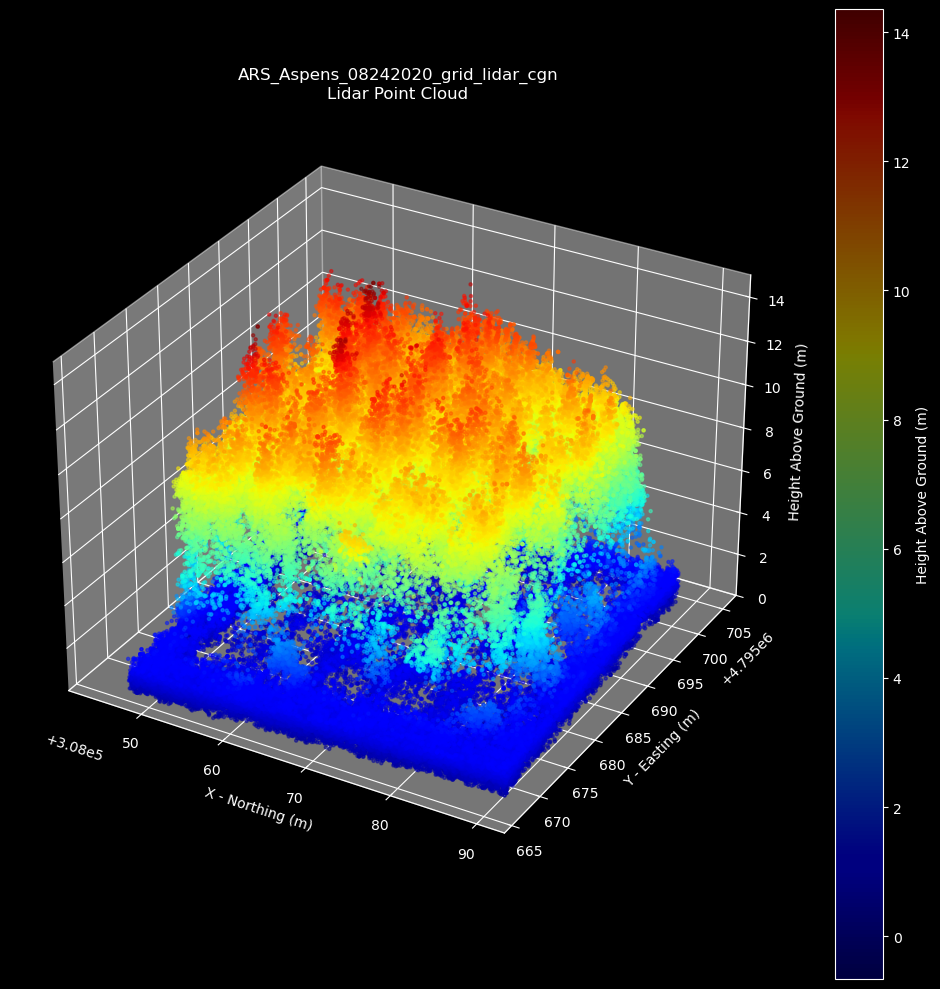

CPU times: user 13.5 s, sys: 371 ms, total: 13.9 s
Wall time: 11.4 s


In [7]:
%%time
#%matplotlib ipympl
import pdal
import matplotlib.pyplot as plt

# TEST PDAL installation with LiDAR TILE
# ------------------------------------------ #
# 1 - Create simple PDAL pipeline
#   - Read in the las file
#   - Decimate the points
pipeline = pdal.Pipeline()
pipeline |= pdal.Reader.las(filename=las_file)
pipeline |= pdal.Filter.decimation(step=decimate)

# 2- Execute pipeline
pipeline.execute()
arrays = pipeline.arrays[0]

# 3 - Create 3D Figure Frame for points
fig = plt.figure(figsize=fig_size)
ax = fig.add_subplot(111, projection='3d')

# 4 - Access the x, y, z points as numpy arrays
#   - use point threshold to limit the number of points plotted
x = arrays['X'][:point_thresh]
y = arrays['Y'][:point_thresh]
z = arrays['Z'][:point_thresh]

# 5 - Create the scatter plot, coloring by z value
scatter = ax.scatter(x, y, z, c=z, cmap=cmap, marker=mark, alpha=pt_alpha)

# 6 - Add a colorbar
cbar = fig.colorbar(scatter)

# 7 - Set the colorbar label
cbar.set_label('Height Above Ground (m)', fontsize=10)

# 8 - Set labels for the axes
ax.set_xlabel('X - Northing (m)')
ax.set_ylabel('Y - Easting (m)')
ax.set_zlabel('Height Above Ground (m)', fontsize=10)
ax.set_title(f"{las_name}\nLidar Point Cloud", fontsize=12)

# 9 - Set height Z-axis limits
ax.set_zlim(zmin,zmax)

# 10 - Show the plot with tight layout
plt.tight_layout()
plt.show()

## 4. Plot Rasters

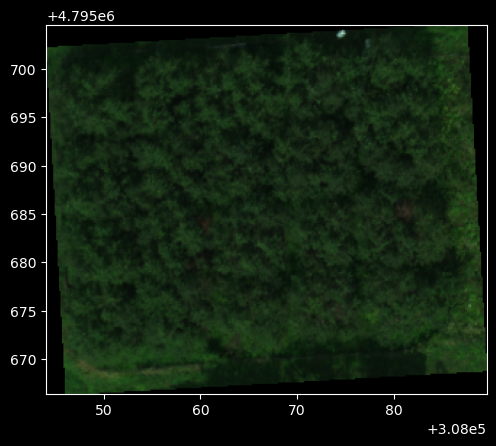

<Axes: >

In [8]:
import rasterio
from rasterio.plot import show

with rasterio.open(rgb_file) as src:
    rgb = src.read([1, 2, 3]) # Read the red, green, and blue bands
    rgb_transform = src.transform

show(rgb, transform=rgb_transform)

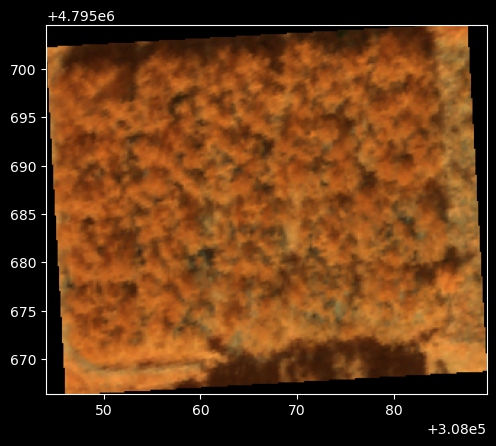

<Axes: >

In [9]:

with rasterio.open(swir_file) as src:
    swir = src.read([1, 2, 3]) # Read the red, green, and blue bands
    swir_transform = src.transform

show(swir, transform=swir_transform)

## 5. Verify Processing Pipeline

This section will test a basic processing pipeline.

The defaults do not to be edited before running the cell:

In [10]:
ras_type  = "RGB"
json_name = f"test_colorize_{ras_type}.json"
json_dir  = f"{wd}/data/json"
json_file = f"{json_dir}/{json_name}"


Use the list trick again to see if the directory is where the variable path points.

In [11]:
!ls -lah $json_dir

total 9.0K
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu   0 Apr 23 13:16 .
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu   0 Apr 24 11:24 ..
-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu 656 Apr 23 13:21 test_colorize_RGB.json


Now, this cell will create a json file in the directory we just listed.

In [12]:
colorized_las = f"{lidar_dir}/{las_name}_COLORS.las"

content = [
    {
        "type": "readers.las",
        "filename": las_file
    },
    {
        "type": "filters.colorization",
        "raster": rgb_file
    },
    {
        "type": "writers.las",
        "filename": colorized_las,
        "minor_version": "4",
        "dataformat_id": "8",
        "scale_z": "1.0",
        "extra_dims": "all",
        "forward": "all"
    }
]

Write that to file.

In [13]:
import json

json_content = json.dumps(content, indent=4)

with open(json_file, 'w') as f:
    f.write(json_content)


Now the file should be listed in the directory.

In [14]:
!ls -lah $json_dir

total 9.0K
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu   0 Apr 23 13:16 .
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu   0 Apr 24 11:24 ..
-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu 656 Apr 28 18:22 test_colorize_RGB.json


Using bash again, we can quickly print the contents to the screen with ```cat```. It should appear in the correctly formatted JSON file structure.

In [15]:
!cat $json_file

[
    {
        "type": "readers.las",
        "filename": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar_cgn.las"
    },
    {
        "type": "filters.colorization",
        "raster": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/tif/ARLINGTON-ARS_20200824_02_Refl_rgb_clip.tif"
    },
    {
        "type": "writers.las",
        "filename": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar_cgn_COLORS.las",
        "minor_version": "4",
        "dataformat_id": "8",
        "scale_z": "1.0",
        "extra_dims": "all",
        "forward": "all"
    }
]

Now execute the pipeline to run the tile.

In [16]:
%%time
import pdal

col_pipeline = pdal.Pipeline(json_content)
col_count = col_pipeline.execute()

# Then use the bash list command to see if the file exists as expected
!ls -lah $colorized_las

-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu 65M Apr 28 18:23 /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar_cgn_COLORS.las
CPU times: user 2.69 s, sys: 378 ms, total: 3.07 s
Wall time: 3.84 s


The executed pipeline output can be plotted using the methods shown above to show the Z values, however, the new attributes aren't as easy to display.

Alternatively, to view the colorized cloud easily, QGIS with PDAL built-in can render tiles with different attributes in both the 2D and 3D views.


![QGIS 2d Map View - SWIR Colorized Cloud](../graphics/CloudRunner-qgis-2d-colors-swir.png)


![QGIS 3d Map View - SWIR Colorized Cloud](../graphics/CloudRunner-qgis-3d-colors-swir.png)


This is the end of this notebook. Please proceed to the next notebook for Single Tile Processing.